# Setup and Reproducibility

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from scipy import stats

# PyTorch & Torchvision
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

# Metrics & Evaluation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

# IEEE Standard Reproducibility Seed
SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ Libraries Loaded Successfully! Using Device: {device}')
if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')

✅ Libraries Loaded Successfully! Using Device: cuda
GPU Name: Tesla T4


# Dataset Exploration

In [2]:

DATASET_PATH = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage'

all_classes = sorted(os.listdir(DATASET_PATH))
print(f'Total classes found: {len(all_classes)}')
print()
for cls in all_classes:
    path = os.path.join(DATASET_PATH, cls)
    count = len(os.listdir(path))
    print(f'  {cls}  ({count} images)')

Total classes found: 15

  Pepper__bell___Bacterial_spot  (997 images)
  Pepper__bell___healthy  (1478 images)
  Potato___Early_blight  (1000 images)
  Potato___Late_blight  (1000 images)
  Potato___healthy  (152 images)
  Tomato_Bacterial_spot  (2127 images)
  Tomato_Early_blight  (1000 images)
  Tomato_Late_blight  (1909 images)
  Tomato_Leaf_Mold  (952 images)
  Tomato_Septoria_leaf_spot  (1771 images)
  Tomato_Spider_mites_Two_spotted_spider_mite  (1676 images)
  Tomato__Target_Spot  (1404 images)
  Tomato__Tomato_YellowLeaf__Curl_Virus  (3209 images)
  Tomato__Tomato_mosaic_virus  (373 images)
  Tomato_healthy  (1591 images)


# EDA 

In [3]:
TARGET_CROPS = ['Tomato', 'Potato', 'Pepper']

filtered_classes = [
    cls for cls in all_classes
    if any(cls.startswith(crop) for crop in TARGET_CROPS)
]

records = []
for cls in filtered_classes:
    path = os.path.join(DATASET_PATH, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    crop = cls.split('_')[0]
    records.append({'class_name': cls, 'crop': crop, 'count': count})

df_eda = pd.DataFrame(records)
print(f'Total Filtered Classes: {len(df_eda)}')
print(f'Total Images: {df_eda["count"].sum():,}')
display(df_eda.head(10))

Total Filtered Classes: 15
Total Images: 20,638


,class_name,crop,count
0,Pepper__bell___Bacterial_spot,Pepper,997
1,Pepper__bell___healthy,Pepper,1478
2,Potato___Early_blight,Potato,1000
3,Potato___Late_blight,Potato,1000
4,Potato___healthy,Potato,152
5,Tomato_Bacterial_spot,Tomato,2127
6,Tomato_Early_blight,Tomato,1000
7,Tomato_Late_blight,Tomato,1909
8,Tomato_Leaf_Mold,Tomato,952
9,Tomato_Septoria_leaf_spot,Tomato,1771


# Data Visualization

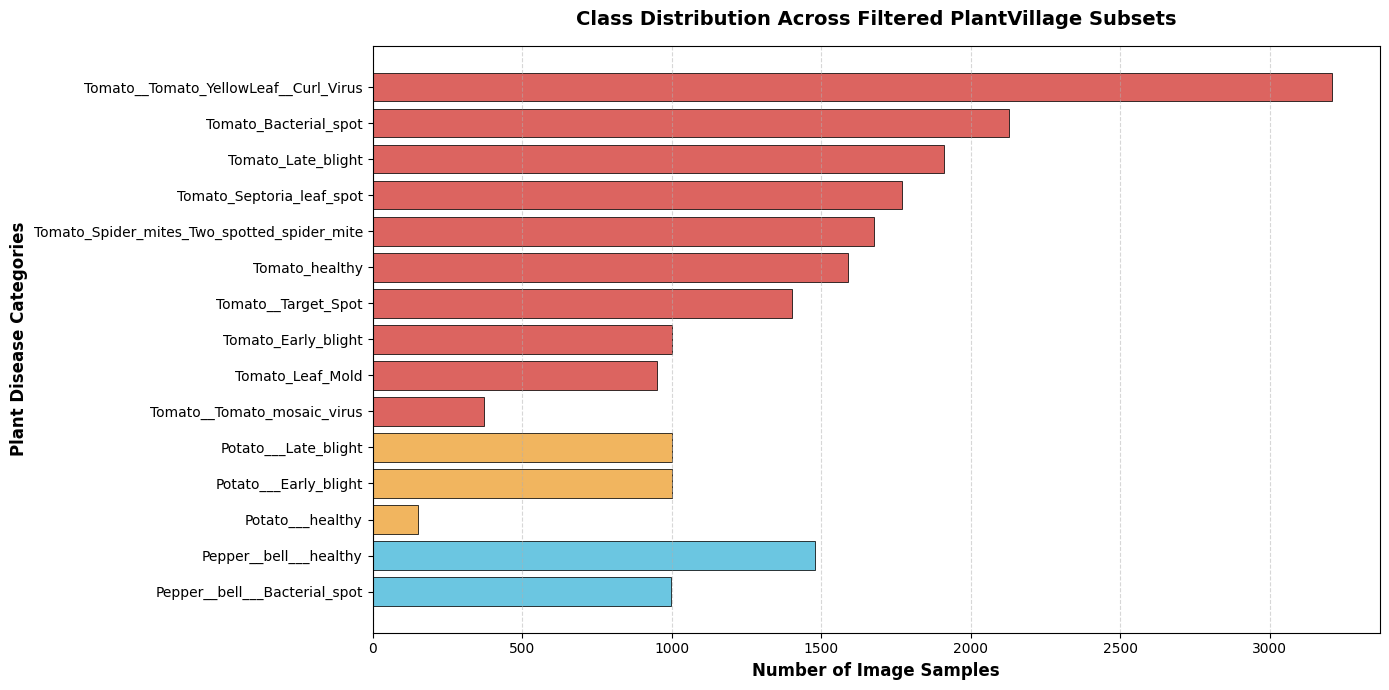

In [4]:
plt.figure(figsize=(14, 7))
crop_colors = {'Tomato': '#d9534f', 'Potato': '#f0ad4e', 'Pepper': '#5bc0de'}

df_sorted = df_eda.sort_values(by=['crop', 'count'], ascending=[True, True])
bars = plt.barh(df_sorted['class_name'], df_sorted['count'], 
                color=[crop_colors[x] for x in df_sorted['crop']], alpha=0.9, edgecolor='black', linewidth=0.6)

plt.title('Class Distribution Across Filtered PlantVillage Subsets', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Image Samples', fontsize=12, fontweight='bold')
plt.ylabel('Plant Disease Categories', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('ieee_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

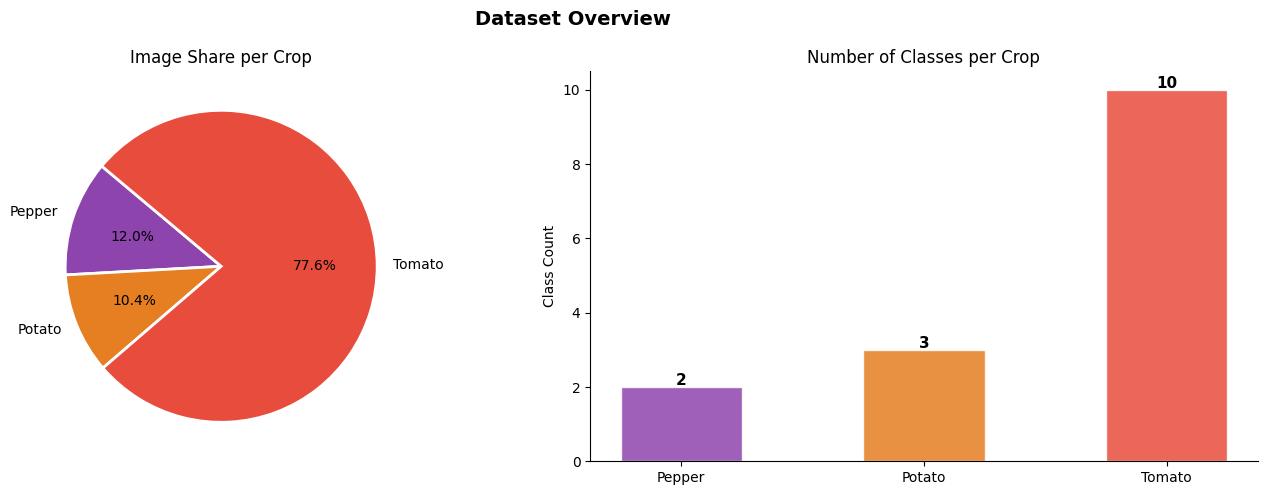

In [5]:
df = pd.DataFrame(records)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# Pie — images per crop
crop_totals = df.groupby('crop')['count'].sum()
colors_pie  = ['#8e44ad', '#e67e22', '#e74c3c']
axes[0].pie(crop_totals, labels=crop_totals.index,
            autopct='%1.1f%%', colors=colors_pie,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=140)
axes[0].set_title('Image Share per Crop')

# Bar — class count per crop
crop_class_count = df.groupby('crop').size()
bars = axes[1].bar(crop_class_count.index, crop_class_count.values,
                   color=colors_pie, alpha=0.85, edgecolor='white', width=0.5)
axes[1].set_title('Number of Classes per Crop')
axes[1].set_ylabel('Class Count')
axes[1].spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, crop_class_count.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 str(val), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

Total images scanned: 20,638
Width  — min:256, max:256, mean:256.0
Height — min:256, max:256, mean:256.0


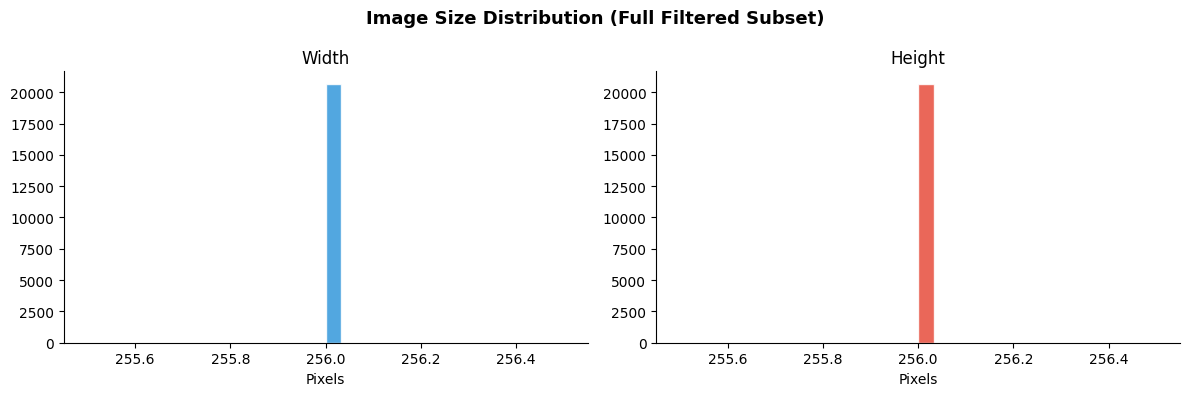

In [6]:
widths, heights = [], []

for cls in filtered_classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for img_name in imgs:   # full scan, no sampling
        try:
            w, h = Image.open(os.path.join(cls_path, img_name)).size
            widths.append(w); heights.append(h)
        except Exception:
            pass  # corrupt/unreadable file, skip silently

print(f'Total images scanned: {len(widths):,}')
print(f'Width  — min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.1f}')
print(f'Height — min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Image Size Distribution (Full Filtered Subset)', fontsize=13, fontweight='bold')
axes[0].hist(widths,  bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Width');  axes[0].set_xlabel('Pixels')
axes[1].hist(heights, bins=30, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1].set_title('Height'); axes[1].set_xlabel('Pixels')
for ax in axes:
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('image_size_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Data Augmentation

In [7]:
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

print('✅ Augmentation pipelines defined (224x224, for BasicCNN / ConvNeXt-Tiny / Swin-Tiny)!')

✅ Augmentation pipelines defined (224x224, for BasicCNN / ConvNeXt-Tiny / Swin-Tiny)!


Selected classes for figure: ['Tomato_Early_blight', 'Tomato_Bacterial_spot', 'Potato___healthy', 'Potato___Late_blight', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']


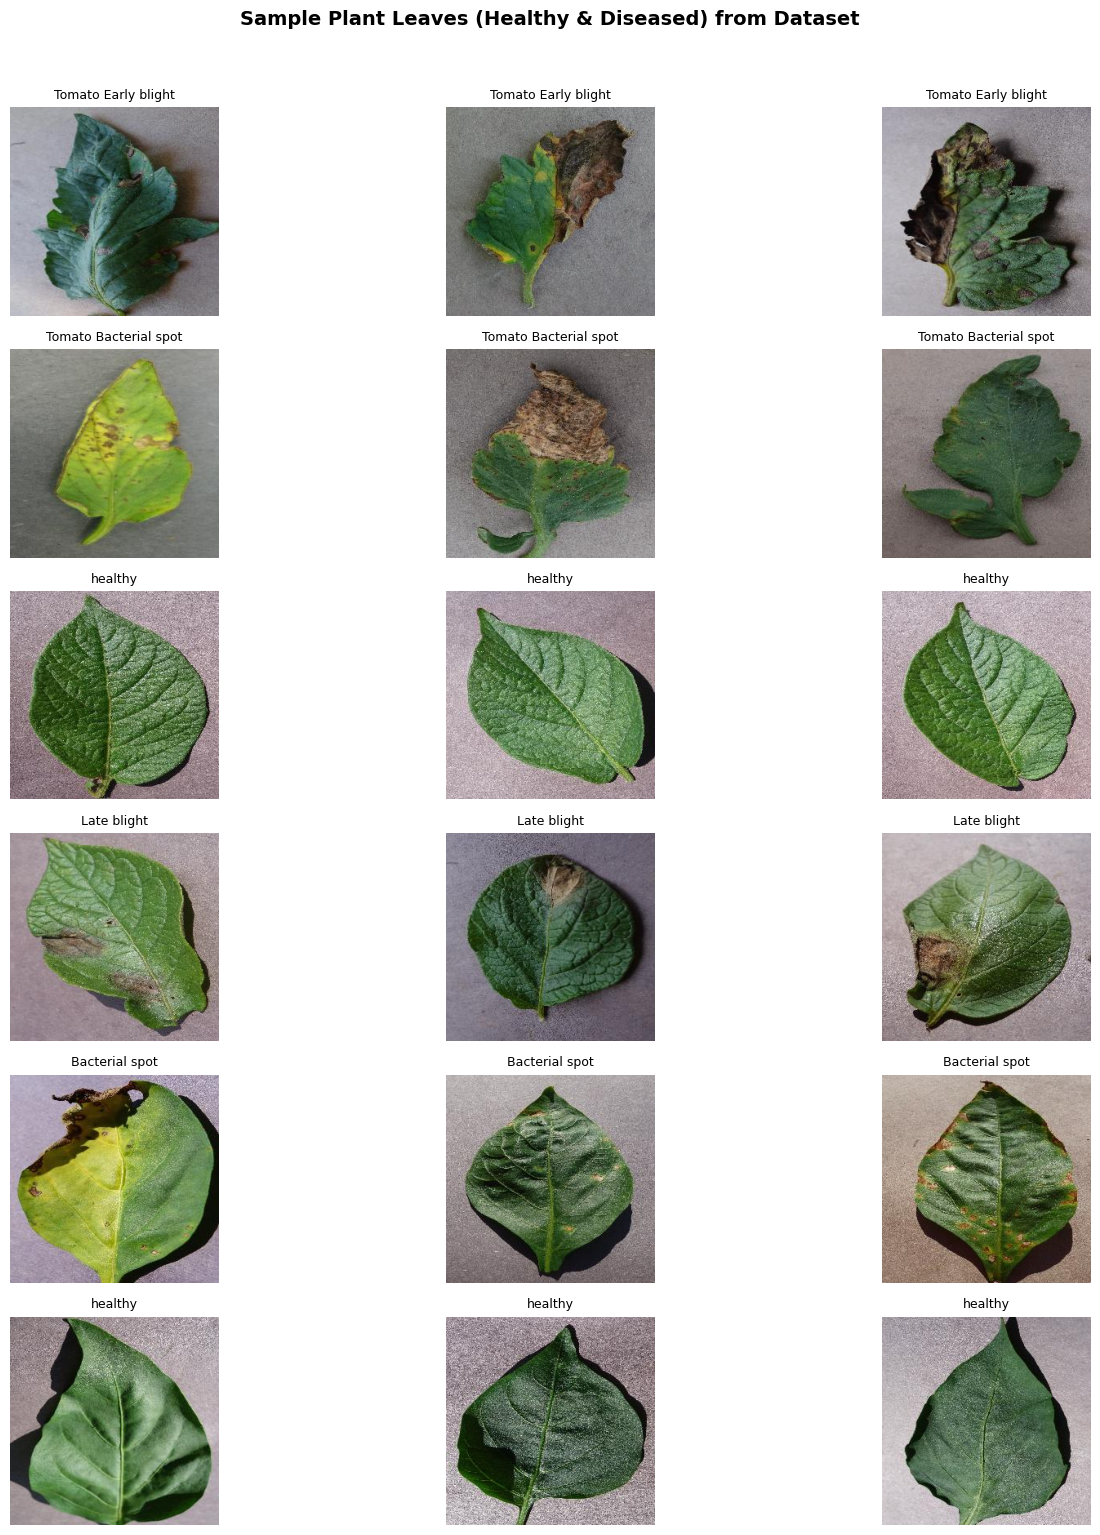

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random

# Number of sample images to display per class
NUM_SAMPLES_PER_CLASS = 3

# Prottek crop (Tomato/Potato/Pepper) theke balanced vabe class select kortesi,
# jate alphabetical order er karone kono crop (jemon Tomato) figure theke bad na pore
random.seed(SEED)
selected_classes = []
for crop in TARGET_CROPS:
    crop_classes = [cls for cls in filtered_classes if cls.startswith(crop)]
    n_pick = min(2, len(crop_classes))  # প্রতি crop theke 2 ti class
    selected_classes.extend(random.sample(crop_classes, n_pick))

print(f'Selected classes for figure: {selected_classes}')

plt.figure(figsize=(15, len(selected_classes) * 2.5))

subplot_idx = 1
for cls in selected_classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Randomly select sample images
    sampled_images = random.sample(images, min(NUM_SAMPLES_PER_CLASS, len(images)))

    for img_name in sampled_images:
        plt.subplot(len(selected_classes), NUM_SAMPLES_PER_CLASS, subplot_idx)
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)

        plt.imshow(img)
        # Clean class name for title (e.g., removing prefix codes if any)
        clean_title = cls.split('___')[-1].replace('_', ' ')
        plt.title(f"{clean_title}", fontsize=9)
        plt.axis('off')
        subplot_idx += 1

plt.suptitle('Sample Plant Leaves (Healthy & Diseased) from Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ieee_eda_sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
full_dataset = datasets.ImageFolder(root=DATASET_PATH)
target_class_indices = [full_dataset.class_to_idx[cls] for cls in filtered_classes]
idx_map = {old_idx: new_idx for new_idx, old_idx in enumerate(target_class_indices)}

filtered_samples = [(path, idx_map[target]) for path, target in full_dataset.samples if target in target_class_indices]

class PlantDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        try:
            image = Image.open(path).convert('RGB')
        except Exception as e:
            print(f'⚠️ Corrupt image skipped: {path} ({e})')
            # fallback: next valid sample e shift kore dei (infinite loop avoid korte modulo)
            return self.__getitem__((idx + 1) % len(self.samples))
        if self.transform:
            image = self.transform(image)
        return image, target

dataset = PlantDataset(filtered_samples)
targets = [s[1] for s in filtered_samples]
print(f'✅ Total Filtered Samples Ready for Cross-Validation: {len(dataset):,}')

✅ Total Filtered Samples Ready for Cross-Validation: 20,638


In [10]:
from sklearn.model_selection import train_test_split

train_idx, temp_idx = train_test_split(
    np.arange(len(filtered_samples)),
    test_size=0.30,
    stratify=targets,
    random_state=SEED
)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_targets,
    random_state=SEED
)

print(f'✅ Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

# ✅ Split indices save kore rakhtesi reproducibility documentation-er jonno
os.makedirs('/kaggle/working/splits', exist_ok=True)
np.save('/kaggle/working/splits/train_idx.npy', train_idx)
np.save('/kaggle/working/splits/val_idx.npy', val_idx)
np.save('/kaggle/working/splits/test_idx.npy', test_idx)
print('💾 Split indices saved to /kaggle/working/splits/')

train_loader = DataLoader(PlantDataset(Subset(filtered_samples, train_idx), train_transforms),
                           batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(PlantDataset(Subset(filtered_samples, val_idx), val_transforms),
                           batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(PlantDataset(Subset(filtered_samples, test_idx), val_transforms),
                           batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

master_results = {}

✅ Train: 14446 | Val: 3096 | Test: 3096
💾 Split indices saved to /kaggle/working/splits/


In [11]:
!pip install imagehash --quiet

In [12]:
import imagehash
from PIL import Image

def compute_hashes(indices, samples, desc=''):
    hashes = {}
    for idx in indices:
        path, label = samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            h = imagehash.phash(img)
            hashes[idx] = h
        except Exception as e:
            print(f'⚠️ Could not hash {path}: {e}')
    return hashes

print('Computing perceptual hashes for train and test sets...')
train_hashes = compute_hashes(train_idx, filtered_samples, 'train')
test_hashes = compute_hashes(test_idx, filtered_samples, 'test')
print(f'✅ Hashed {len(train_hashes)} train images, {len(test_hashes)} test images')

# Compare every test image against every train image (hamming distance <= threshold = near-duplicate)
THRESHOLD = 5  # phash hamming distance; 0 = identical, <=5 = visually near-identical
leaked_pairs = []

test_items = list(test_hashes.items())
train_items = list(train_hashes.items())

for test_idx_val, test_h in test_items:
    for train_idx_val, train_h in train_items:
        dist = test_h - train_h  # hamming distance
        if dist <= THRESHOLD:
            leaked_pairs.append((test_idx_val, train_idx_val, dist))

print(f'\n🔍 Found {len(leaked_pairs)} near-duplicate pairs between train and test sets (threshold={THRESHOLD})')

if len(leaked_pairs) > 0:
    print(f'⚠️ This affects {len(set(p[0] for p in leaked_pairs))} unique test images '
          f'out of {len(test_idx)} total test images '
          f'({len(set(p[0] for p in leaked_pairs))/len(test_idx)*100:.2f}%)')

    # Show a few example pairs
    print('\nExample leaked pairs (test_idx, train_idx, hamming_distance):')
    for p in leaked_pairs[:5]:
        print(p)
else:
    print('✅ No near-duplicate leakage detected between train and test sets.')

Computing perceptual hashes for train and test sets...
✅ Hashed 14446 train images, 3096 test images

🔍 Found 13 near-duplicate pairs between train and test sets (threshold=5)
⚠️ This affects 13 unique test images out of 3096 total test images (0.42%)

Example leaked pairs (test_idx, train_idx, hamming_distance):
(np.int64(16190), np.int64(15535), 4)
(np.int64(13140), np.int64(13230), 2)
(np.int64(18422), np.int64(17674), 4)
(np.int64(8682), np.int64(8027), 4)
(np.int64(5368), np.int64(17745), 4)


In [13]:
leaked_test_indices = set(p[0] for p in leaked_pairs)
test_idx = np.array([i for i in test_idx if i not in leaked_test_indices])
print(f'✅ Test set cleaned: dropped {len(leaked_test_indices)} leaked images → new test size: {len(test_idx)}')

test_loader = DataLoader(PlantDataset(Subset(filtered_samples, test_idx), val_transforms),
                          batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

✅ Test set cleaned: dropped 13 leaked images → new test size: 3083


In [14]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def get_model(model_name, num_classes):
    if model_name == 'BasicCNN':
        model = BasicCNN(num_classes)

    elif model_name == 'ConvNeXt-Tiny':
        weights = torchvision.models.ConvNeXt_Tiny_Weights.DEFAULT
        model = torchvision.models.convnext_tiny(weights=weights)
        for param in model.features.parameters():
            param.requires_grad = False
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)

    elif model_name == 'EfficientNet-B4':
        weights = torchvision.models.EfficientNet_B4_Weights.DEFAULT
        model = torchvision.models.efficientnet_b4(weights=weights)
        for param in model.features.parameters():
            param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == 'Swin-Tiny':
        weights = torchvision.models.Swin_T_Weights.DEFAULT
        model = torchvision.models.swin_t(weights=weights)
        for param in model.features.parameters():
            param.requires_grad = False
        in_features = model.head.in_features
        model.head = nn.Linear(in_features, num_classes)

    else:
        raise ValueError("Unsupported model name!")

    return model.to(device)


def train_one_model(model_name, epochs):
    print(f'\n======================================================')
    print(f'🚀 TRAINING & EVALUATING ARCHITECTURE: {model_name}')
    print(f'======================================================')

    model = get_model(model_name, num_classes=len(filtered_classes))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=1)

    train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist = [], [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        epoch_val_loss = val_running_loss / val_total
        epoch_val_acc = val_correct / val_total
        scheduler.step(epoch_val_loss)

        train_loss_hist.append(epoch_train_loss)
        val_loss_hist.append(epoch_val_loss)
        train_acc_hist.append(epoch_train_acc)
        val_acc_hist.append(epoch_val_acc)

        print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%')

    model.eval()
    test_preds, test_targets, test_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            test_preds.extend(predicted.cpu().numpy())
            test_targets.extend(labels.cpu().numpy())
            test_probs.extend(probs.cpu().numpy())

    test_acc = accuracy_score(test_targets, test_preds)

    master_results[model_name] = {
        'accuracies': [test_acc],
        'mean_acc': test_acc,
        'std_acc': 0.0,
        'preds': test_preds,
        'targets': test_targets,
        'probs': np.array(test_probs),
        'sample_idx': test_idx.tolist(),
        'history': {
            'train_loss': train_loss_hist, 'val_loss': val_loss_hist,
            'train_acc': train_acc_hist,   'val_acc': val_acc_hist
        }
    }
    return model

print('✅ Model factory + training function ready!')

✅ Model factory + training function ready!


In [15]:
EPOCHS = 15
basic_cnn_model = train_one_model('BasicCNN', EPOCHS)


🚀 TRAINING & EVALUATING ARCHITECTURE: BasicCNN
Epoch [1/15] | Train Loss: 1.4553 | Train Acc: 53.59% | Val Loss: 0.9958 | Val Acc: 66.41%
Epoch [2/15] | Train Loss: 0.9830 | Train Acc: 67.66% | Val Loss: 0.5702 | Val Acc: 82.95%
Epoch [3/15] | Train Loss: 0.7822 | Train Acc: 73.97% | Val Loss: 0.6200 | Val Acc: 78.49%
Epoch [4/15] | Train Loss: 0.6452 | Train Acc: 78.53% | Val Loss: 0.4766 | Val Acc: 83.82%
Epoch [5/15] | Train Loss: 0.5609 | Train Acc: 81.39% | Val Loss: 0.4240 | Val Acc: 85.79%
Epoch [6/15] | Train Loss: 0.4872 | Train Acc: 83.73% | Val Loss: 0.3064 | Val Acc: 89.21%
Epoch [7/15] | Train Loss: 0.4527 | Train Acc: 84.98% | Val Loss: 0.2913 | Val Acc: 89.92%
Epoch [8/15] | Train Loss: 0.4297 | Train Acc: 85.86% | Val Loss: 0.2179 | Val Acc: 93.22%
Epoch [9/15] | Train Loss: 0.3860 | Train Acc: 87.34% | Val Loss: 0.2260 | Val Acc: 91.67%
Epoch [10/15] | Train Loss: 0.3636 | Train Acc: 88.27% | Val Loss: 0.2661 | Val Acc: 91.12%
Epoch [11/15] | Train Loss: 0.2758 | Trai

In [16]:
def quick_eval(model_name):
    result = master_results[model_name]

    # 1. Classification Report
    print(f'\n📊 Classification Report — {model_name}')
    print(classification_report(result['targets'], result['preds'], target_names=filtered_classes))

    # 2. Confusion Matrix
    cm = confusion_matrix(result['targets'], result['preds'])
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=filtered_classes, yticklabels=filtered_classes,
                annot_kws={'size': 7}, cbar=True)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=14)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=90, ha='center', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

    # 3. Train/Val Loss & Accuracy Curve
    hist = result['history']
    epochs_range = range(1, len(hist['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_range, hist['train_loss'], label='Train Loss')
    axes[0].plot(epochs_range, hist['val_loss'], label='Val Loss')
    axes[0].set_title(f'{model_name} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs_range, hist['train_acc'], label='Train Acc')
    axes[1].plot(epochs_range, hist['val_acc'], label='Val Acc')
    axes[1].set_title(f'{model_name} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f'✅ Test Accuracy — {model_name}: {result["mean_acc"]*100:.2f}%')


📊 Classification Report — BasicCNN
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.97      0.98       149
                     Pepper__bell___healthy       1.00      1.00      1.00       219
                      Potato___Early_blight       0.99      0.97      0.98       150
                       Potato___Late_blight       0.94      0.93      0.94       150
                           Potato___healthy       1.00      0.91      0.95        23
                      Tomato_Bacterial_spot       0.98      0.98      0.98       317
                        Tomato_Early_blight       0.91      0.83      0.86       150
                         Tomato_Late_blight       0.94      0.93      0.93       284
                           Tomato_Leaf_Mold       0.97      0.98      0.98       143
                  Tomato_Septoria_leaf_spot       0.94      0.99      0.97       266
Tomato_Spider_mites_Two_spot

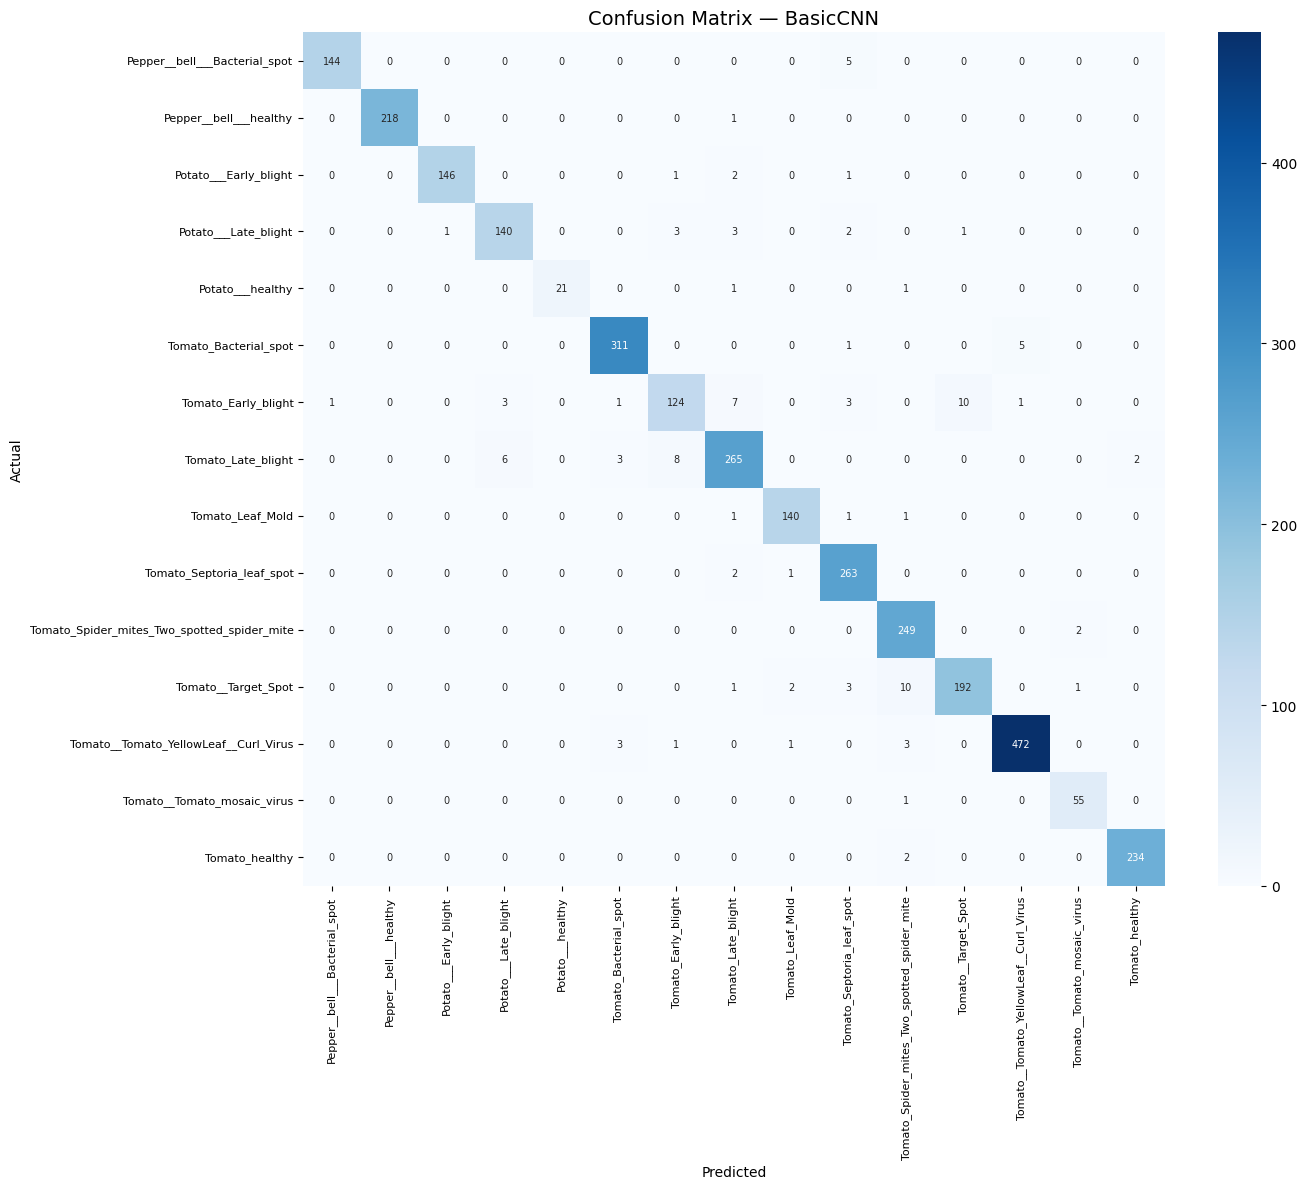

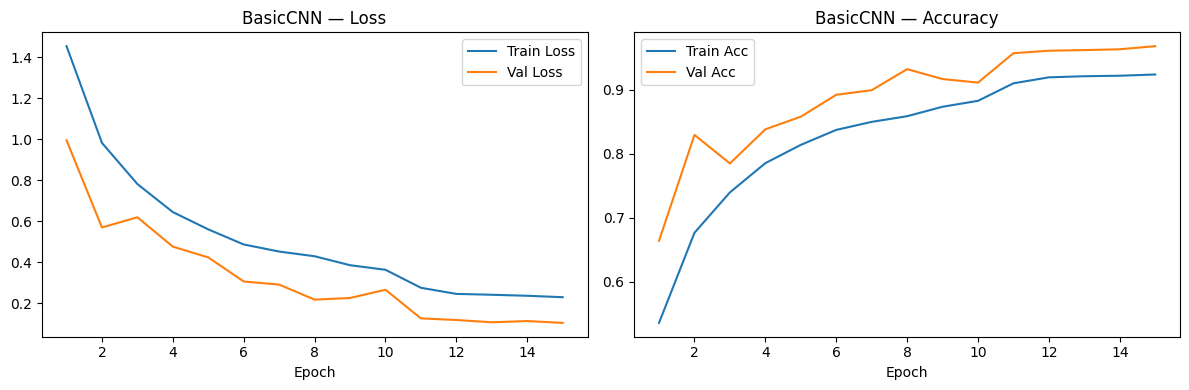

✅ Test Accuracy — BasicCNN: 96.46%


In [17]:
quick_eval('BasicCNN')


In [18]:
convnext_model = train_one_model('ConvNeXt-Tiny', 15)


🚀 TRAINING & EVALUATING ARCHITECTURE: ConvNeXt-Tiny
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 206MB/s] 


Epoch [1/15] | Train Loss: 0.6585 | Train Acc: 84.24% | Val Loss: 0.2808 | Val Acc: 93.28%
Epoch [2/15] | Train Loss: 0.2322 | Train Acc: 93.92% | Val Loss: 0.1784 | Val Acc: 95.06%
Epoch [3/15] | Train Loss: 0.1657 | Train Acc: 95.51% | Val Loss: 0.1503 | Val Acc: 95.64%
Epoch [4/15] | Train Loss: 0.1342 | Train Acc: 96.19% | Val Loss: 0.1173 | Val Acc: 96.87%
Epoch [5/15] | Train Loss: 0.1127 | Train Acc: 96.86% | Val Loss: 0.1010 | Val Acc: 97.06%
Epoch [6/15] | Train Loss: 0.1010 | Train Acc: 97.21% | Val Loss: 0.0992 | Val Acc: 97.00%
Epoch [7/15] | Train Loss: 0.0889 | Train Acc: 97.47% | Val Loss: 0.0939 | Val Acc: 96.96%
Epoch [8/15] | Train Loss: 0.0838 | Train Acc: 97.55% | Val Loss: 0.0823 | Val Acc: 97.42%
Epoch [9/15] | Train Loss: 0.0736 | Train Acc: 97.83% | Val Loss: 0.0858 | Val Acc: 96.96%
Epoch [10/15] | Train Loss: 0.0703 | Train Acc: 97.97% | Val Loss: 0.0750 | Val Acc: 97.51%
Epoch [11/15] | Train Loss: 0.0698 | Train Acc: 97.90% | Val Loss: 0.0716 | Val Acc: 97.8


📊 Classification Report — ConvNeXt-Tiny
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      1.00      1.00       149
                     Pepper__bell___healthy       0.99      1.00      1.00       219
                      Potato___Early_blight       1.00      0.99      1.00       150
                       Potato___Late_blight       0.99      0.97      0.98       150
                           Potato___healthy       0.92      1.00      0.96        23
                      Tomato_Bacterial_spot       0.98      0.99      0.99       317
                        Tomato_Early_blight       0.94      0.91      0.92       150
                         Tomato_Late_blight       0.97      0.97      0.97       284
                           Tomato_Leaf_Mold       1.00      0.96      0.98       143
                  Tomato_Septoria_leaf_spot       0.98      0.98      0.98       266
Tomato_Spider_mites_Two

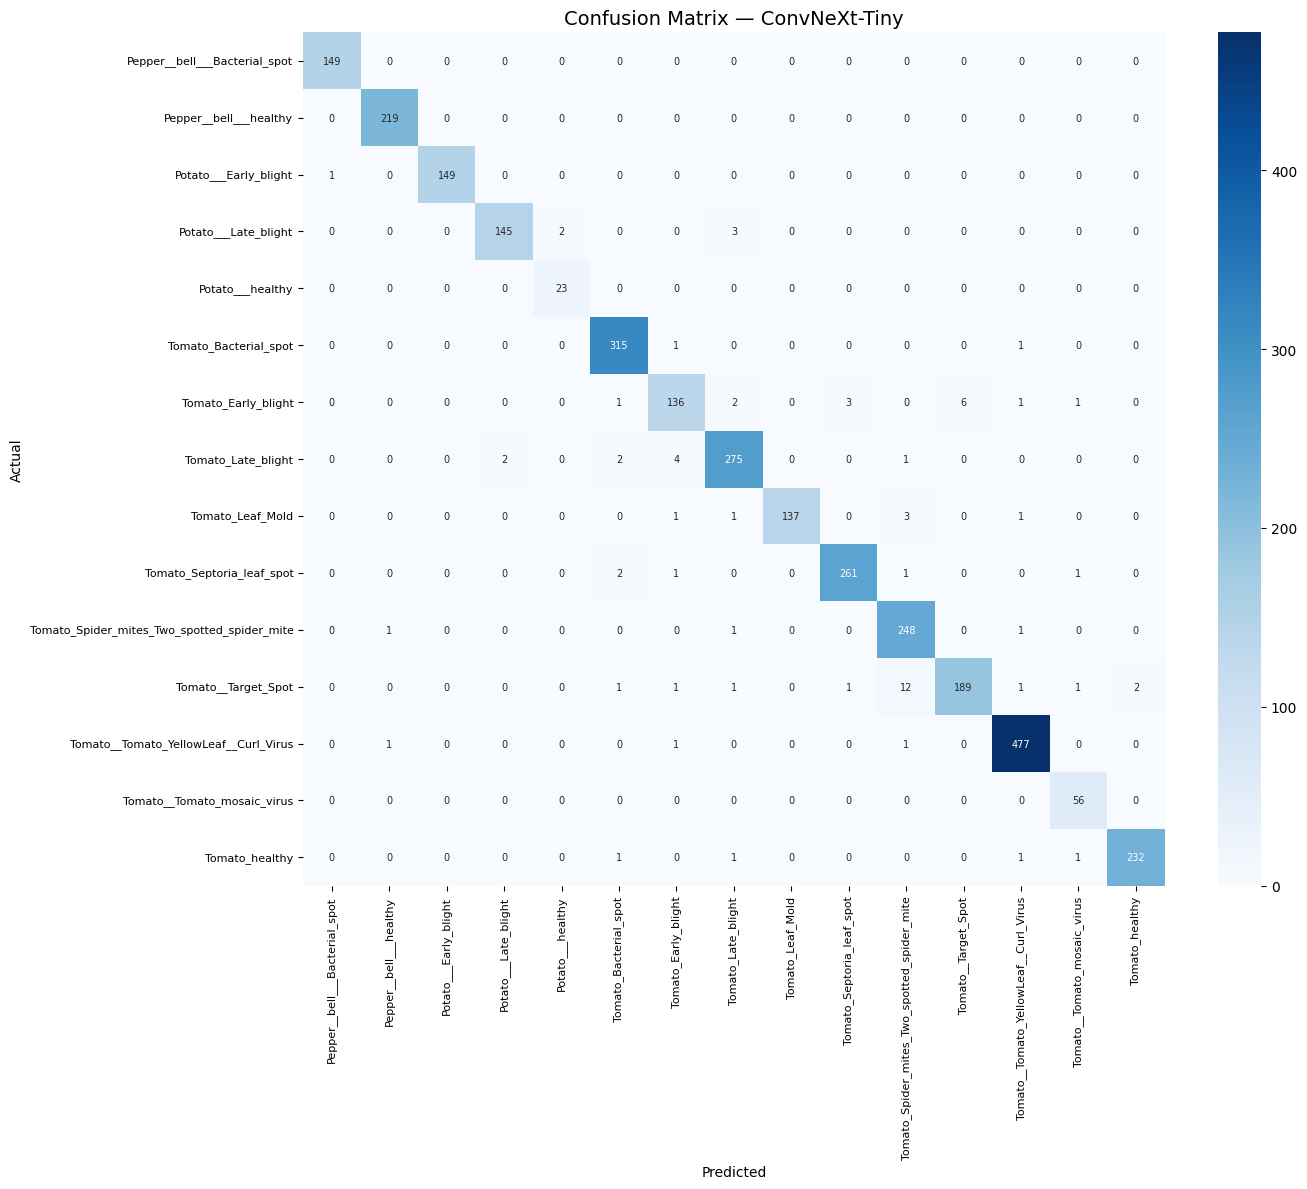

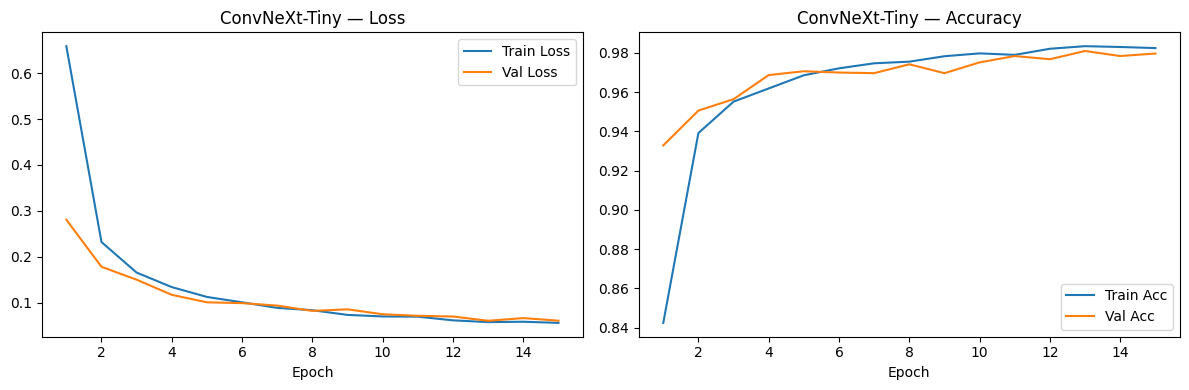

✅ Test Accuracy — ConvNeXt-Tiny: 97.66%


In [19]:
quick_eval('ConvNeXt-Tiny')

In [20]:
b4_train_transforms = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

b4_val_transforms = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

b4_train_loader = DataLoader(PlantDataset(Subset(filtered_samples, train_idx), b4_train_transforms),
                              batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
b4_val_loader   = DataLoader(PlantDataset(Subset(filtered_samples, val_idx), b4_val_transforms),
                              batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
b4_test_loader  = DataLoader(PlantDataset(Subset(filtered_samples, test_idx), b4_val_transforms),
                              batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print('✅ 380x380 loader ready for EfficientNet-B4   ')

✅ 380x380 loader ready for EfficientNet-B4   


In [21]:
def train_one_model_b4(model_name, epochs, tr_loader, va_loader, te_loader):
    print(f'\n======================================================')
    print(f'🚀 TRAINING & EVALUATING ARCHITECTURE: {model_name} (380x380)')
    print(f'======================================================')

    model = get_model(model_name, num_classes=len(filtered_classes))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=1)

    train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist = [], [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in tr_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in va_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        epoch_val_loss = val_running_loss / val_total
        epoch_val_acc = val_correct / val_total
        scheduler.step(epoch_val_loss)

        train_loss_hist.append(epoch_train_loss)
        val_loss_hist.append(epoch_val_loss)
        train_acc_hist.append(epoch_train_acc)
        val_acc_hist.append(epoch_val_acc)

        print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%')

    model.eval()
    test_preds, test_targets, test_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in te_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            test_preds.extend(predicted.cpu().numpy())
            test_targets.extend(labels.cpu().numpy())
            test_probs.extend(probs.cpu().numpy())

    test_acc = accuracy_score(test_targets, test_preds)

    master_results[model_name] = {
        'accuracies': [test_acc],
        'mean_acc': test_acc,
        'std_acc': 0.0,
        'preds': test_preds,
        'targets': test_targets,
        'probs': np.array(test_probs),
        'sample_idx': test_idx.tolist(),
        'history': {
            'train_loss': train_loss_hist, 'val_loss': val_loss_hist,
            'train_acc': train_acc_hist,   'val_acc': val_acc_hist
        }
    }
    return model


efficientnet_model = train_one_model_b4('EfficientNet-B4', 15, b4_train_loader, b4_val_loader, b4_test_loader)


🚀 TRAINING & EVALUATING ARCHITECTURE: EfficientNet-B4 (380x380)
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 165MB/s] 


Epoch [1/15] | Train Loss: 1.4134 | Train Acc: 67.07% | Val Loss: 0.8352 | Val Acc: 82.40%
Epoch [2/15] | Train Loss: 0.7792 | Train Acc: 80.08% | Val Loss: 0.5796 | Val Acc: 86.98%
Epoch [3/15] | Train Loss: 0.6362 | Train Acc: 82.25% | Val Loss: 0.4760 | Val Acc: 88.66%
Epoch [4/15] | Train Loss: 0.5752 | Train Acc: 83.05% | Val Loss: 0.4131 | Val Acc: 89.86%
Epoch [5/15] | Train Loss: 0.5321 | Train Acc: 83.87% | Val Loss: 0.3841 | Val Acc: 90.63%
Epoch [6/15] | Train Loss: 0.5028 | Train Acc: 84.31% | Val Loss: 0.3479 | Val Acc: 91.05%
Epoch [7/15] | Train Loss: 0.4845 | Train Acc: 84.81% | Val Loss: 0.3260 | Val Acc: 91.57%
Epoch [8/15] | Train Loss: 0.4746 | Train Acc: 84.67% | Val Loss: 0.3162 | Val Acc: 91.47%
Epoch [9/15] | Train Loss: 0.4687 | Train Acc: 84.91% | Val Loss: 0.2968 | Val Acc: 91.80%
Epoch [10/15] | Train Loss: 0.4614 | Train Acc: 85.17% | Val Loss: 0.2933 | Val Acc: 92.02%
Epoch [11/15] | Train Loss: 0.4603 | Train Acc: 85.06% | Val Loss: 0.2836 | Val Acc: 92.2


📊 Classification Report — EfficientNet-B4
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.90      0.97      0.93       149
                     Pepper__bell___healthy       0.97      0.98      0.98       219
                      Potato___Early_blight       0.96      0.96      0.96       150
                       Potato___Late_blight       0.92      0.94      0.93       150
                           Potato___healthy       0.89      0.70      0.78        23
                      Tomato_Bacterial_spot       0.95      0.95      0.95       317
                        Tomato_Early_blight       0.92      0.73      0.81       150
                         Tomato_Late_blight       0.94      0.90      0.92       284
                           Tomato_Leaf_Mold       0.85      0.92      0.88       143
                  Tomato_Septoria_leaf_spot       0.85      0.93      0.89       266
Tomato_Spider_mites_T

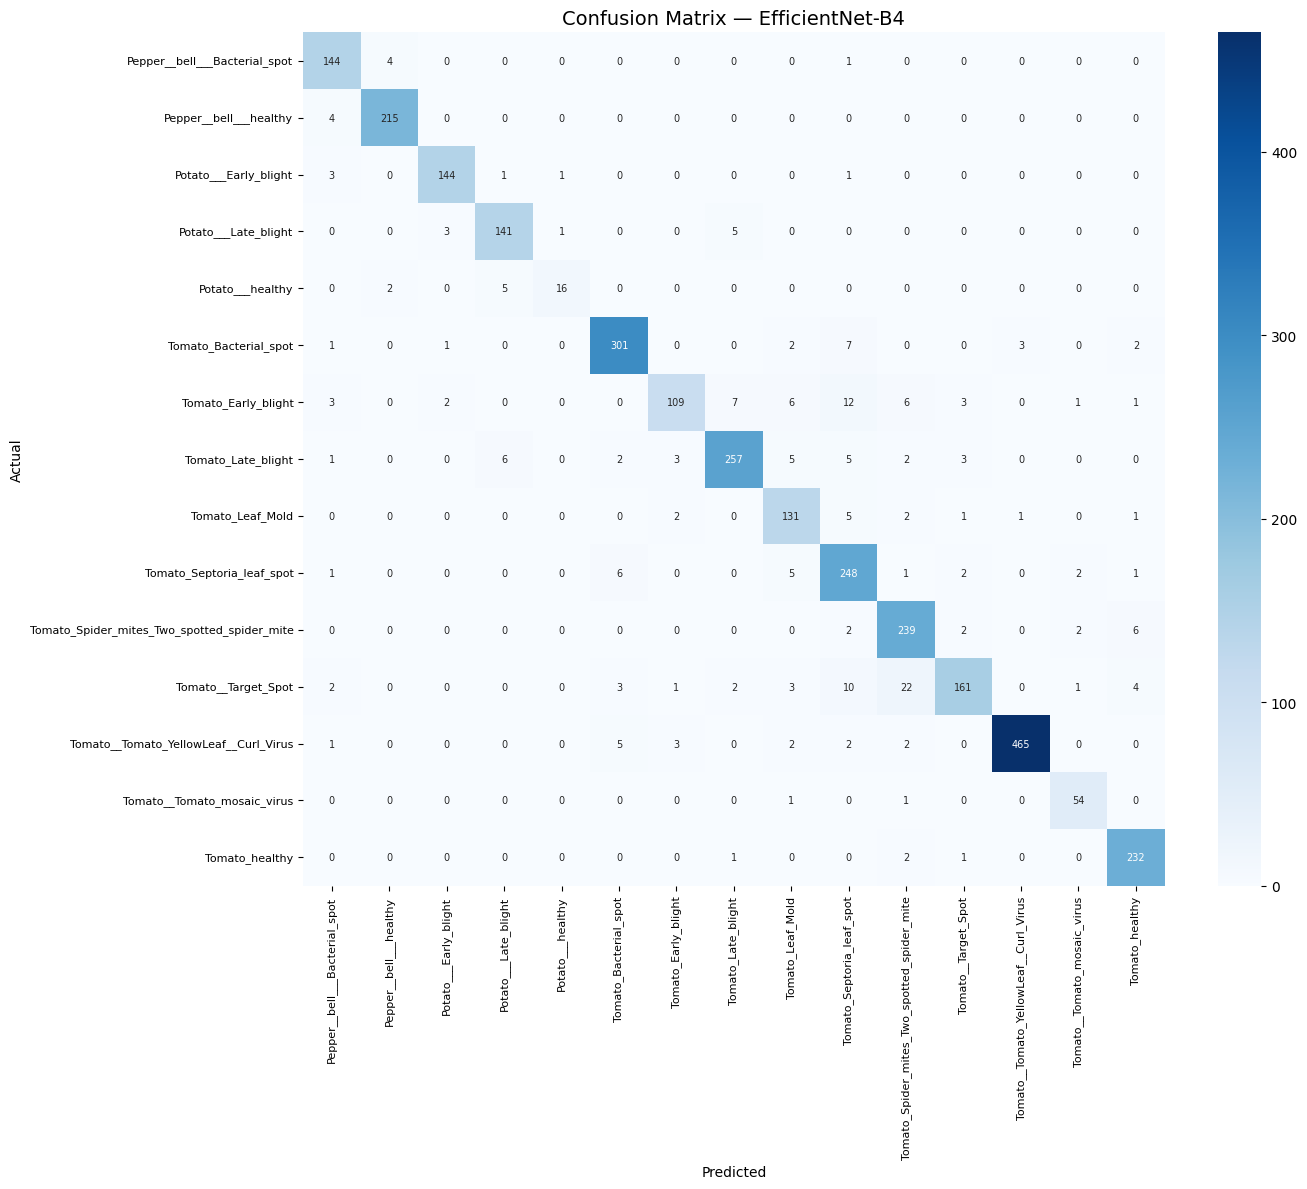

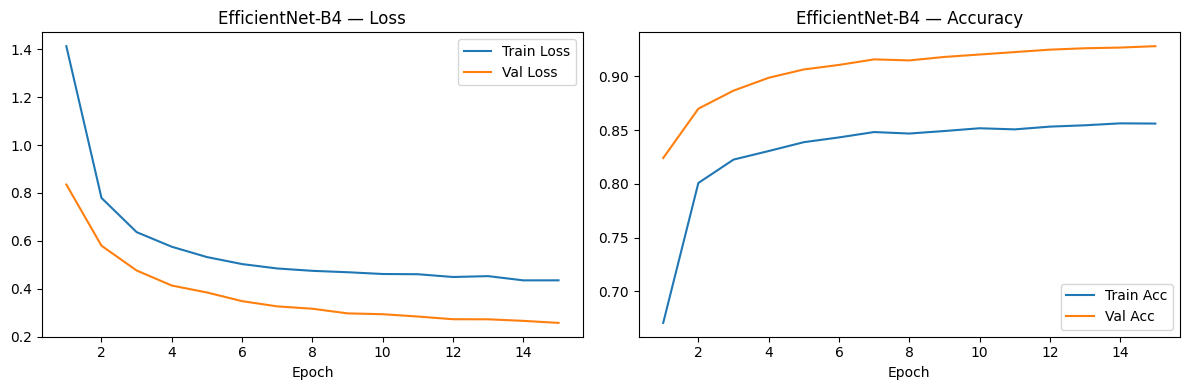

✅ Test Accuracy — EfficientNet-B4: 92.67%


In [22]:
quick_eval('EfficientNet-B4')

In [23]:
swin_model = train_one_model('Swin-Tiny', 15)


🚀 TRAINING & EVALUATING ARCHITECTURE: Swin-Tiny
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 188MB/s]  


Epoch [1/15] | Train Loss: 0.7726 | Train Acc: 80.43% | Val Loss: 0.3517 | Val Acc: 91.67%
Epoch [2/15] | Train Loss: 0.3282 | Train Acc: 91.32% | Val Loss: 0.2399 | Val Acc: 93.73%
Epoch [3/15] | Train Loss: 0.2465 | Train Acc: 93.12% | Val Loss: 0.1919 | Val Acc: 94.77%
Epoch [4/15] | Train Loss: 0.2070 | Train Acc: 94.03% | Val Loss: 0.1697 | Val Acc: 95.09%
Epoch [5/15] | Train Loss: 0.1912 | Train Acc: 94.35% | Val Loss: 0.1543 | Val Acc: 95.35%
Epoch [6/15] | Train Loss: 0.1685 | Train Acc: 94.86% | Val Loss: 0.1390 | Val Acc: 95.87%
Epoch [7/15] | Train Loss: 0.1518 | Train Acc: 95.60% | Val Loss: 0.1227 | Val Acc: 96.22%
Epoch [8/15] | Train Loss: 0.1458 | Train Acc: 95.76% | Val Loss: 0.1185 | Val Acc: 96.19%
Epoch [9/15] | Train Loss: 0.1408 | Train Acc: 95.78% | Val Loss: 0.1124 | Val Acc: 96.48%
Epoch [10/15] | Train Loss: 0.1291 | Train Acc: 96.09% | Val Loss: 0.1094 | Val Acc: 96.54%
Epoch [11/15] | Train Loss: 0.1258 | Train Acc: 96.17% | Val Loss: 0.1044 | Val Acc: 96.1


📊 Classification Report — Swin-Tiny
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      1.00      0.99       149
                     Pepper__bell___healthy       1.00      1.00      1.00       219
                      Potato___Early_blight       0.99      1.00      0.99       150
                       Potato___Late_blight       0.99      0.97      0.98       150
                           Potato___healthy       0.96      0.96      0.96        23
                      Tomato_Bacterial_spot       0.95      1.00      0.98       317
                        Tomato_Early_blight       0.87      0.87      0.87       150
                         Tomato_Late_blight       0.98      0.96      0.97       284
                           Tomato_Leaf_Mold       0.95      0.99      0.97       143
                  Tomato_Septoria_leaf_spot       0.99      0.92      0.96       266
Tomato_Spider_mites_Two_spo

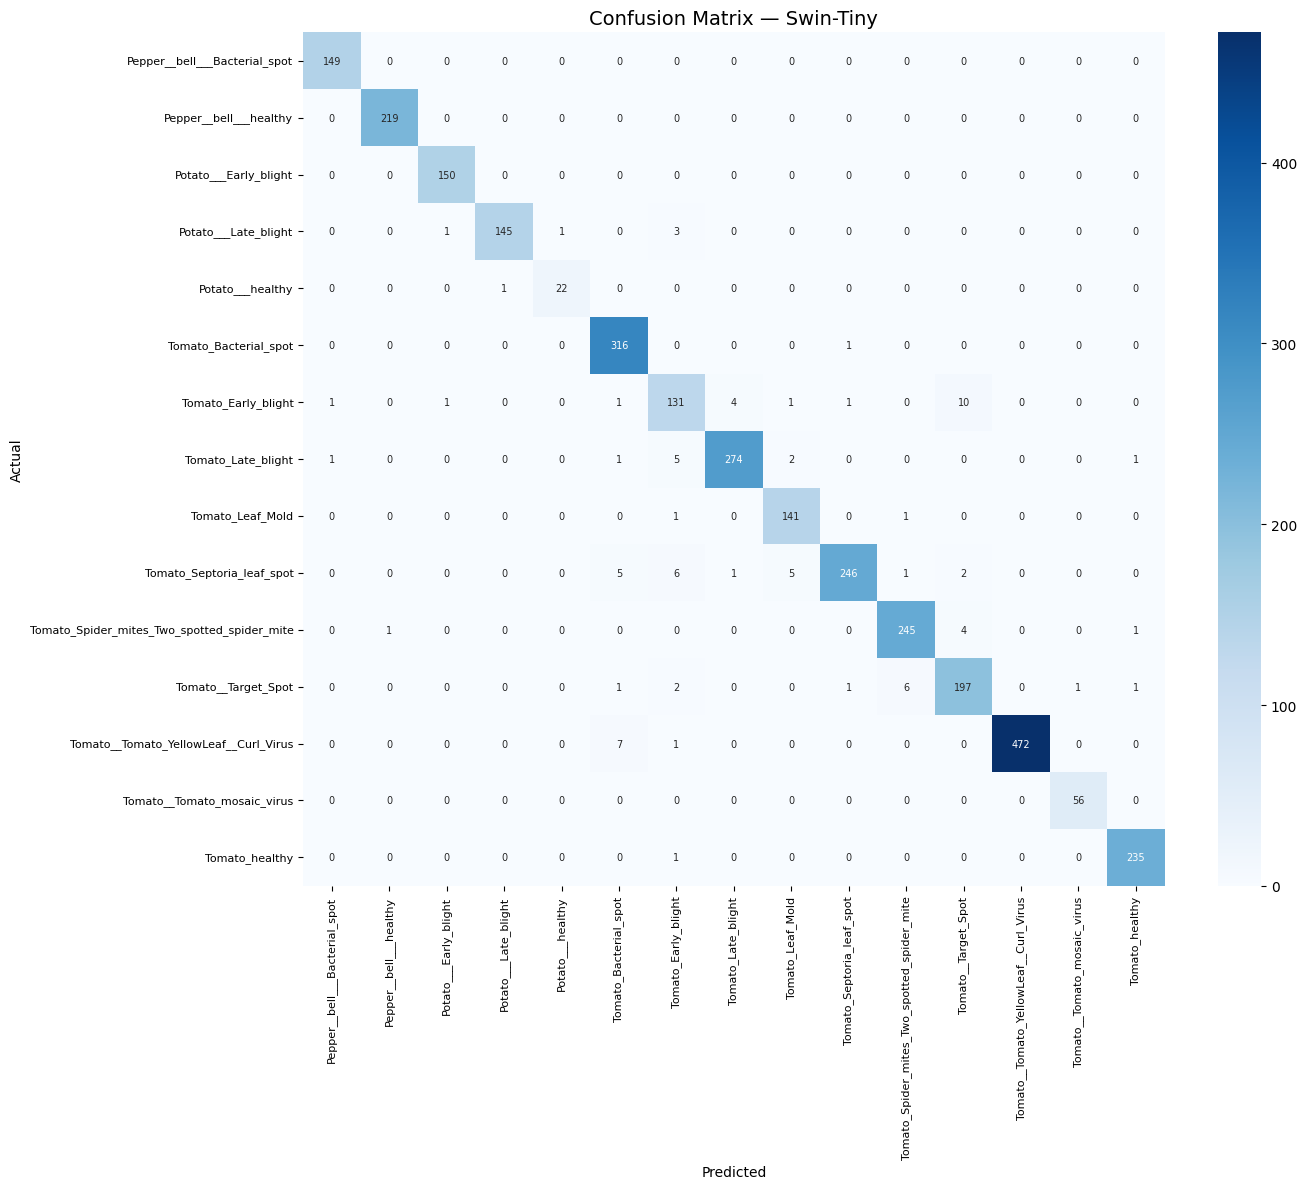

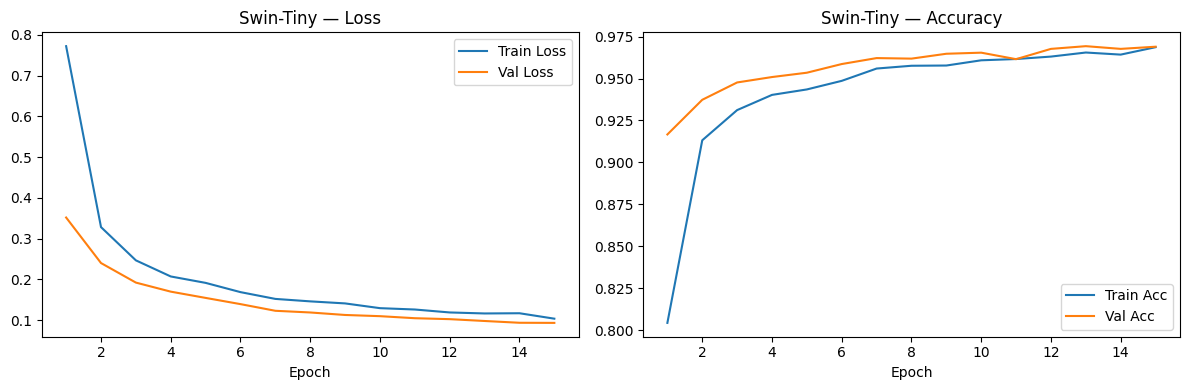

✅ Test Accuracy — Swin-Tiny: 97.24%


In [24]:
quick_eval('Swin-Tiny')

🎯 Soft-Voting Fusion (ConvNeXt-Tiny + Swin-Tiny) Test Accuracy: 98.48%
   ConvNeXt-Tiny alone : 97.66%
   Swin-Tiny alone     : 97.24%

📊 Classification Report — Soft-Voting Fusion
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       149
                     Pepper__bell___healthy       1.00      1.00      1.00       219
                      Potato___Early_blight       0.99      1.00      1.00       150
                       Potato___Late_blight       1.00      0.97      0.99       150
                           Potato___healthy       0.96      1.00      0.98        23
                      Tomato_Bacterial_spot       0.98      1.00      0.99       317
                        Tomato_Early_blight       0.97      0.91      0.94       150
                         Tomato_Late_blight       0.98      0.98      0.98       284
                           Tomato_Leaf_Mold       0.9

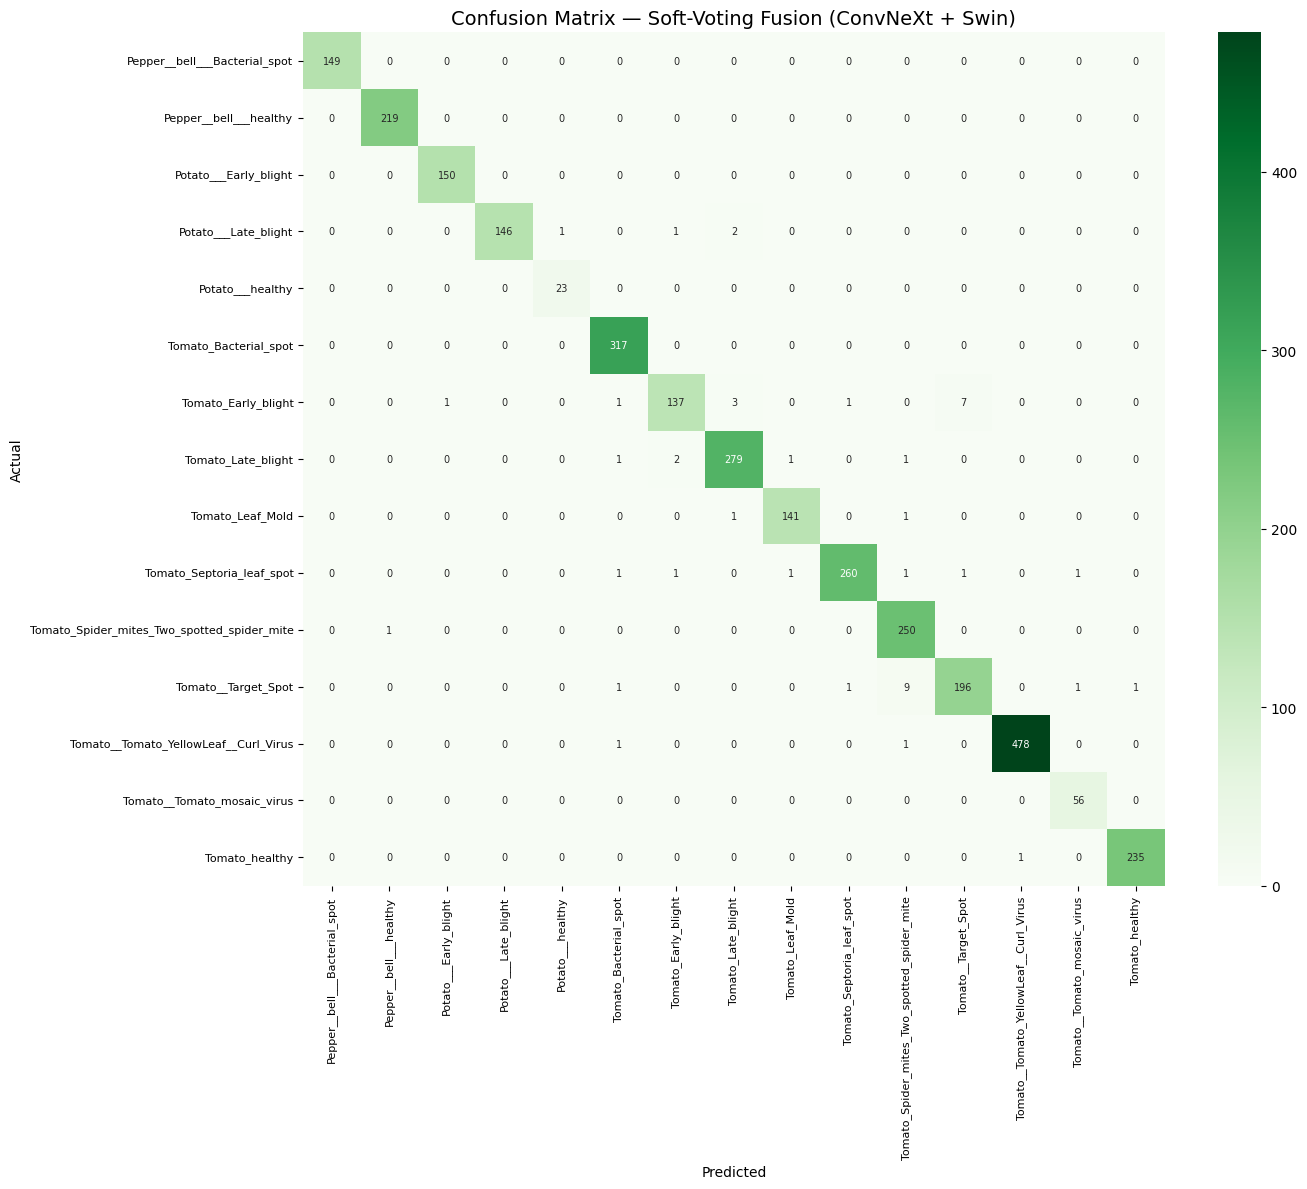

In [25]:
r1 = master_results['ConvNeXt-Tiny']
r2 = master_results['Swin-Tiny']

# both models predicted on the same test_idx, so targets align
assert r1['targets'] == r2['targets'], 'Target mismatch — dui model er test set alada hoye gese!'

fused_probs = (r1['probs'] + r2['probs']) / 2.0
fused_preds = np.argmax(fused_probs, axis=1)
fused_targets = r1['targets']

fused_acc = accuracy_score(fused_targets, fused_preds)
print(f'🎯 Soft-Voting Fusion (ConvNeXt-Tiny + Swin-Tiny) Test Accuracy: {fused_acc*100:.2f}%')
print(f'   ConvNeXt-Tiny alone : {r1["mean_acc"]*100:.2f}%')
print(f'   Swin-Tiny alone     : {r2["mean_acc"]*100:.2f}%')

print('\n📊 Classification Report — Soft-Voting Fusion')
print(classification_report(fused_targets, fused_preds, target_names=filtered_classes))

cm = confusion_matrix(fused_targets, fused_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=filtered_classes, yticklabels=filtered_classes,
            annot_kws={'size': 7})
plt.title('Confusion Matrix — Soft-Voting Fusion (ConvNeXt + Swin)', fontsize=14)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=90, fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

master_results['Fusion-SoftVoting'] = {
    'accuracies': [fused_acc], 'mean_acc': fused_acc, 'std_acc': 0.0,
    'preds': fused_preds.tolist(), 'targets': fused_targets,
    'probs': fused_probs, 'sample_idx': test_idx.tolist()
}

In [26]:
def get_penultimate_extractor(model, model_name):
    if model_name == 'ConvNeXt-Tiny':
        return nn.Sequential(model.features, model.avgpool, nn.Flatten())
    elif model_name == 'Swin-Tiny':
        return nn.Sequential(model.features, model.norm, model.permute, model.avgpool, nn.Flatten())
    else:
        raise ValueError('Unsupported')

convnext_extractor = get_penultimate_extractor(convnext_model, 'ConvNeXt-Tiny').to(device).eval()
swin_extractor = get_penultimate_extractor(swin_model, 'Swin-Tiny').to(device).eval()

def extract_features(extractor, loader):
    feats, labels_all = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            f = extractor(inputs)
            feats.append(f.cpu())
            labels_all.append(labels)
    return torch.cat(feats), torch.cat(labels_all)

# ✅ train/val/test 
print('Extracting features (train)...')
convnext_train_feats, train_feat_labels = extract_features(convnext_extractor, train_loader)
swin_train_feats, _ = extract_features(swin_extractor, train_loader)

print('Extracting features (val)...')
convnext_val_feats, val_feat_labels = extract_features(convnext_extractor, val_loader)
swin_val_feats, _ = extract_features(swin_extractor, val_loader)

print('Extracting features (test)...')
convnext_test_feats, test_feat_labels = extract_features(convnext_extractor, test_loader)
swin_test_feats, _ = extract_features(swin_extractor, test_loader)

fused_train_feats = torch.cat([convnext_train_feats, swin_train_feats], dim=1)
fused_val_feats   = torch.cat([convnext_val_feats, swin_val_feats], dim=1)
fused_test_feats  = torch.cat([convnext_test_feats, swin_test_feats], dim=1)
print(f'Fused feature dim: {fused_train_feats.shape[1]}')

class FeatureDataset(torch.utils.data.Dataset):
    def __init__(self, feats, labels):
        self.feats, self.labels = feats, labels
    def __len__(self):
        return len(self.feats)
    def __getitem__(self, idx):
        return self.feats[idx], self.labels[idx]

feat_train_loader = DataLoader(FeatureDataset(fused_train_feats, train_feat_labels), batch_size=32, shuffle=True)
feat_val_loader   = DataLoader(FeatureDataset(fused_val_feats, val_feat_labels), batch_size=32, shuffle=False)
feat_test_loader  = DataLoader(FeatureDataset(fused_test_feats, test_feat_labels), batch_size=32, shuffle=False)

class FusionHead(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.net(x)

fusion_head = FusionHead(fused_train_feats.shape[1], len(filtered_classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fusion_head.parameters(), lr=0.001)

for epoch in range(15):
    fusion_head.train()
    correct, total = 0, 0
    for feats, labels in feat_train_loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = fusion_head(feats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    fusion_head.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels in feat_val_loader:
            feats, labels = feats.to(device), labels.to(device)
            outputs = fusion_head(feats)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    print(f'Epoch [{epoch+1}/15] | Train Acc: {correct/total*100:.2f}% | Val Acc: {val_correct/val_total*100:.2f}%')

# ✅ Final test 
fusion_head.eval()
test_preds, test_targets = [], []
with torch.no_grad():
    for feats, labels in feat_test_loader:
        feats, labels = feats.to(device), labels.to(device)
        outputs = fusion_head(feats)
        _, predicted = outputs.max(1)
        test_preds.extend(predicted.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

feat_fusion_acc = accuracy_score(test_targets, test_preds)
print(f'\n🎯 Feature-Level Fusion Test Accuracy (full untouched test set): {feat_fusion_acc*100:.2f}%')
print('\n📊 Classification Report — Feature-Level Fusion')
print(classification_report(test_targets, test_preds, target_names=filtered_classes))

master_results['Fusion-FeatureLevel'] = {
    'accuracies': [feat_fusion_acc], 'mean_acc': feat_fusion_acc, 'std_acc': 0.0,
    'preds': test_preds, 'targets': test_targets
}

Extracting features (train)...
Extracting features (val)...
Extracting features (test)...
Fused feature dim: 1536
Epoch [1/15] | Train Acc: 61.37% | Val Acc: 81.88%
Epoch [2/15] | Train Acc: 84.51% | Val Acc: 86.08%
Epoch [3/15] | Train Acc: 88.92% | Val Acc: 90.63%
Epoch [4/15] | Train Acc: 91.52% | Val Acc: 91.34%
Epoch [5/15] | Train Acc: 93.06% | Val Acc: 92.96%
Epoch [6/15] | Train Acc: 93.90% | Val Acc: 93.02%
Epoch [7/15] | Train Acc: 94.60% | Val Acc: 92.57%
Epoch [8/15] | Train Acc: 95.24% | Val Acc: 93.02%
Epoch [9/15] | Train Acc: 95.96% | Val Acc: 91.89%
Epoch [10/15] | Train Acc: 95.93% | Val Acc: 93.51%
Epoch [11/15] | Train Acc: 96.22% | Val Acc: 93.80%
Epoch [12/15] | Train Acc: 96.65% | Val Acc: 94.02%
Epoch [13/15] | Train Acc: 96.92% | Val Acc: 94.28%
Epoch [14/15] | Train Acc: 97.14% | Val Acc: 94.54%
Epoch [15/15] | Train Acc: 97.19% | Val Acc: 93.22%

🎯 Feature-Level Fusion Test Accuracy (full untouched test set): 93.42%

📊 Classification Report — Feature-Level Fu

In [27]:
from sklearn.model_selection import StratifiedKFold
import pickle

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
all_indices = np.arange(len(filtered_samples))
all_targets_arr = np.array(targets)

cv_results = {'ConvNeXt-Tiny': [], 'Swin-Tiny': [], 'Fusion-SoftVoting': []}
CV_EPOCHS = 15

for fold, (train_val_idx, test_idx_fold) in enumerate(skf.split(all_indices, all_targets_arr)):
    print(f'\n{"="*60}\n🔁 FOLD {fold+1}/5\n{"="*60}')

    fold_train_idx, fold_val_idx = train_test_split(
        train_val_idx, test_size=0.1,
        stratify=all_targets_arr[train_val_idx], random_state=SEED
    )

    fold_train_loader = DataLoader(PlantDataset(Subset(filtered_samples, fold_train_idx), train_transforms),
                                    batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    fold_val_loader = DataLoader(PlantDataset(Subset(filtered_samples, fold_val_idx), val_transforms),
                                  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
    fold_test_loader = DataLoader(PlantDataset(Subset(filtered_samples, test_idx_fold), val_transforms),
                                   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    fold_probs = {}
    fold_targets_arr = None

    for mname in ['ConvNeXt-Tiny', 'Swin-Tiny']:
        model = get_model(mname, num_classes=len(filtered_classes))
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=1)

        for epoch in range(CV_EPOCHS):
            model.train()
            for inputs, labels in fold_train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            model.eval()
            val_loss_total, val_total = 0.0, 0
            with torch.no_grad():
                for inputs, labels in fold_val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss_total += loss.item() * inputs.size(0)
                    val_total += labels.size(0)
            scheduler.step(val_loss_total / val_total)
            print(f'  [{mname}] Epoch {epoch+1}/{CV_EPOCHS} done')

        model.eval()
        preds, tgts, probs = [], [], []
        with torch.no_grad():
            for inputs, labels in fold_test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                p = torch.softmax(outputs, dim=1)
                _, pred = outputs.max(1)
                preds.extend(pred.cpu().numpy())
                tgts.extend(labels.cpu().numpy())
                probs.extend(p.cpu().numpy())

        acc = accuracy_score(tgts, preds)
        cv_results[mname].append(acc)
        fold_probs[mname] = np.array(probs)
        fold_targets_arr = np.array(tgts)
        print(f'✅ Fold {fold+1} | {mname} Test Accuracy: {acc*100:.2f}%')
        del model
        torch.cuda.empty_cache()

    # Soft-voting fusion for this fold
    fused_probs_fold = (fold_probs['ConvNeXt-Tiny'] + fold_probs['Swin-Tiny']) / 2.0
    fused_preds_fold = np.argmax(fused_probs_fold, axis=1)
    fused_acc_fold = accuracy_score(fold_targets_arr, fused_preds_fold)
    cv_results['Fusion-SoftVoting'].append(fused_acc_fold)
    print(f'✅ Fold {fold+1} | Fusion Test Accuracy: {fused_acc_fold*100:.2f}%')

    # Save progress after every fold (in case of session drop)
    with open('/kaggle/working/cv_results.pkl', 'wb') as f:
        pickle.dump(cv_results, f)
    print(f'💾 CV progress saved after fold {fold+1}')

print('\n' + '='*60)
print('📊 5-FOLD CROSS-VALIDATION SUMMARY')
print('='*60)
for mname, accs in cv_results.items():
    accs_pct = [a*100 for a in accs]
    print(f'{mname}: {np.mean(accs_pct):.2f}% ± {np.std(accs_pct):.2f}%   (folds: {[f"{a:.2f}" for a in accs_pct]})')


🔁 FOLD 1/5
  [ConvNeXt-Tiny] Epoch 1/15 done
  [ConvNeXt-Tiny] Epoch 2/15 done
  [ConvNeXt-Tiny] Epoch 3/15 done
  [ConvNeXt-Tiny] Epoch 4/15 done
  [ConvNeXt-Tiny] Epoch 5/15 done
  [ConvNeXt-Tiny] Epoch 6/15 done
  [ConvNeXt-Tiny] Epoch 7/15 done
  [ConvNeXt-Tiny] Epoch 8/15 done
  [ConvNeXt-Tiny] Epoch 9/15 done
  [ConvNeXt-Tiny] Epoch 10/15 done
  [ConvNeXt-Tiny] Epoch 11/15 done
  [ConvNeXt-Tiny] Epoch 12/15 done
  [ConvNeXt-Tiny] Epoch 13/15 done
  [ConvNeXt-Tiny] Epoch 14/15 done
  [ConvNeXt-Tiny] Epoch 15/15 done
✅ Fold 1 | ConvNeXt-Tiny Test Accuracy: 97.80%
  [Swin-Tiny] Epoch 1/15 done
  [Swin-Tiny] Epoch 2/15 done
  [Swin-Tiny] Epoch 3/15 done
  [Swin-Tiny] Epoch 4/15 done
  [Swin-Tiny] Epoch 5/15 done
  [Swin-Tiny] Epoch 6/15 done
  [Swin-Tiny] Epoch 7/15 done
  [Swin-Tiny] Epoch 8/15 done
  [Swin-Tiny] Epoch 9/15 done
  [Swin-Tiny] Epoch 10/15 done
  [Swin-Tiny] Epoch 11/15 done
  [Swin-Tiny] Epoch 12/15 done
  [Swin-Tiny] Epoch 13/15 done
  [Swin-Tiny] Epoch 14/15 done


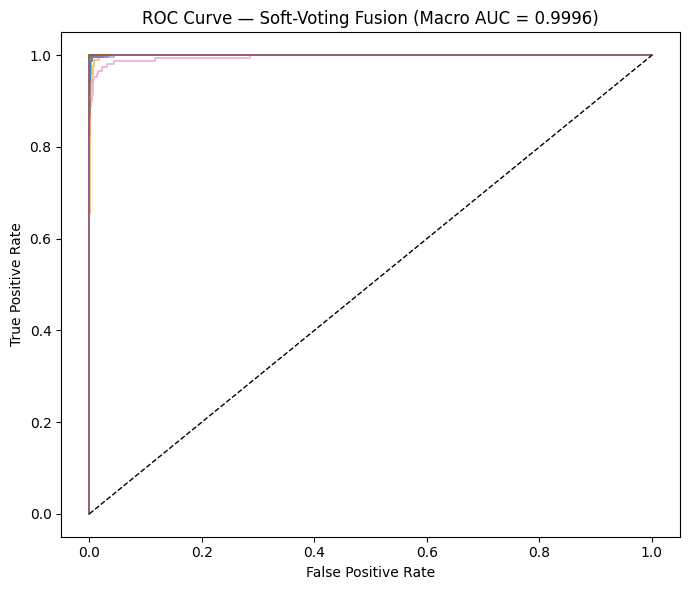

Macro AUC: 0.9996


In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

r = master_results['Fusion-SoftVoting']
y_true_bin = label_binarize(r['targets'], classes=list(range(len(filtered_classes))))
y_probs = r['probs']

plt.figure(figsize=(7, 6))
aucs = []
for c in range(len(filtered_classes)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, c], y_probs[:, c])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, alpha=0.6, linewidth=1.2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — Soft-Voting Fusion (Macro AUC = {np.mean(aucs):.4f})')
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve_fusion.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Macro AUC: {np.mean(aucs):.4f}')

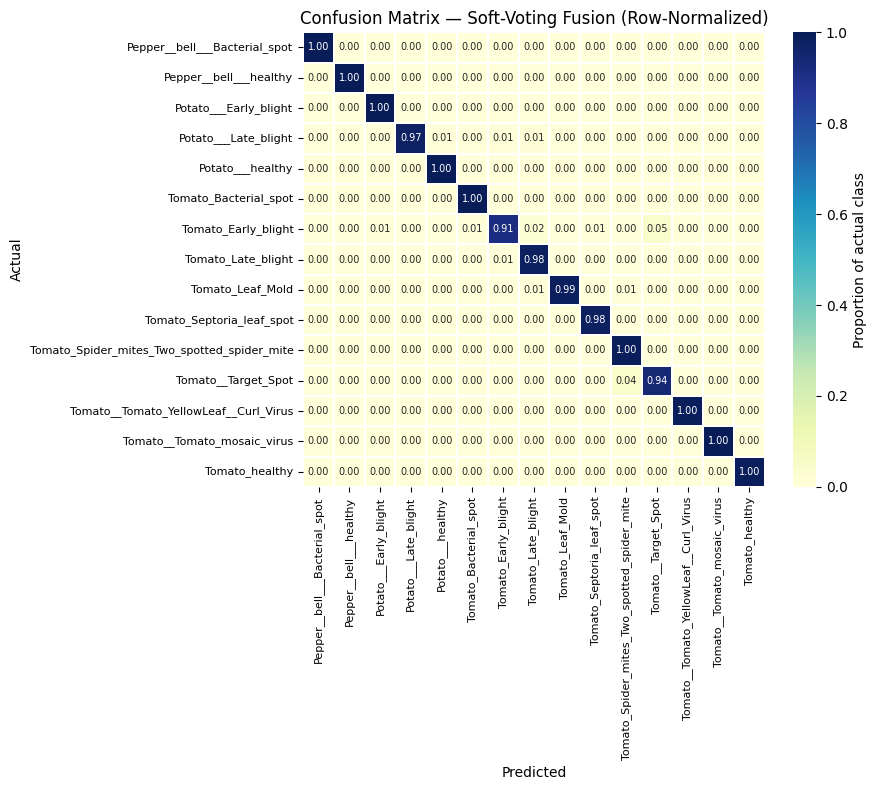

In [29]:
cm = confusion_matrix(r['targets'], r['preds'])
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalized (% of actual class)

plt.figure(figsize=(9, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=filtered_classes, yticklabels=filtered_classes,
            annot_kws={'size': 7}, cbar_kws={'label': 'Proportion of actual class'},
            linewidths=0.3, linecolor='white')
plt.title('Confusion Matrix — Soft-Voting Fusion (Row-Normalized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_fusion.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
import time

loaded_models = {
    'BasicCNN': basic_cnn_model,
    'ConvNeXt-Tiny': convnext_model,
    'EfficientNet-B4': efficientnet_model,
    'Swin-Tiny': swin_model
}

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def measure_inference_time(model, loader, n_batches=20):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (inputs, _) in enumerate(loader):
            if i >= n_batches:
                break
            inputs = inputs.to(device)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            start = time.time()
            _ = model(inputs)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end = time.time()
            times.append((end - start) / inputs.size(0))
    return np.mean(times) * 1000

complexity_rows = []
for mname, model in loaded_models.items():
    total_p, trainable_p = count_params(model)
    loader_for_speed = b4_test_loader if mname == 'EfficientNet-B4' else test_loader
    inf_time = measure_inference_time(model, loader_for_speed)
    complexity_rows.append({
        'Model': mname,
        'Total Params (M)': round(total_p / 1e6, 2),
        'Trainable Params (M)': round(trainable_p / 1e6, 2),
        'Inference Time (ms/img)': round(inf_time, 3),
        'Test Accuracy (%)': round(master_results[mname]['mean_acc'] * 100, 2)
    })

fusion_time = complexity_rows[[r['Model'] for r in complexity_rows].index('ConvNeXt-Tiny')]['Inference Time (ms/img)'] + \
              complexity_rows[[r['Model'] for r in complexity_rows].index('Swin-Tiny')]['Inference Time (ms/img)']
complexity_rows.append({
    'Model': 'Fusion (ConvNeXt+Swin)',
    'Total Params (M)': round(
        complexity_rows[[r['Model'] for r in complexity_rows].index('ConvNeXt-Tiny')]['Total Params (M)'] +
        complexity_rows[[r['Model'] for r in complexity_rows].index('Swin-Tiny')]['Total Params (M)'], 2),
    'Trainable Params (M)': '-',
    'Inference Time (ms/img)': round(fusion_time, 3),
    'Test Accuracy (%)': round(master_results['Fusion-SoftVoting']['mean_acc'] * 100, 2)
})

complexity_df = pd.DataFrame(complexity_rows)
print(complexity_df.to_string(index=False))

                 Model  Total Params (M) Trainable Params (M)  Inference Time (ms/img)  Test Accuracy (%)
              BasicCNN              0.42                 0.42                    0.743              96.46
         ConvNeXt-Tiny             27.83                 0.01                    4.324              97.66
       EfficientNet-B4             17.58                 0.03                   10.083              92.67
             Swin-Tiny             27.53                 0.01                    4.822              97.24
Fusion (ConvNeXt+Swin)             55.36                    -                    9.146              98.48


In [31]:
from statsmodels.stats.contingency_tables import mcnemar

def run_mcnemar(name1, name2):
    r1, r2 = master_results[name1], master_results[name2]
    p1 = np.array(r1['preds']) == np.array(r1['targets'])
    p2 = np.array(r2['preds']) == np.array(r2['targets'])

    both_correct = np.sum(p1 & p2)
    only1_correct = np.sum(p1 & ~p2)
    only2_correct = np.sum(~p1 & p2)
    both_wrong = np.sum(~p1 & ~p2)

    table = [[both_correct, only1_correct], [only2_correct, both_wrong]]
    result = mcnemar(table, exact=False, correction=True)

    sig = 'Significant (p < 0.05)' if result.pvalue < 0.05 else 'Not significant'
    print(f'{name1} vs {name2}: statistic={result.statistic:.4f}, p-value={result.pvalue:.4f} → {sig}')
    return result.pvalue

print('📐 McNemar\'s Test Results\n')
pairs = [
    ('ConvNeXt-Tiny', 'Swin-Tiny'),
    ('ConvNeXt-Tiny', 'Fusion-SoftVoting'),
    ('Swin-Tiny', 'Fusion-SoftVoting'),
    ('BasicCNN', 'Fusion-SoftVoting'),
]
for a, b in pairs:
    run_mcnemar(a, b)

📐 McNemar's Test Results

ConvNeXt-Tiny vs Swin-Tiny: statistic=1.5158, p-value=0.2183 → Not significant
ConvNeXt-Tiny vs Fusion-SoftVoting: statistic=15.5676, p-value=0.0001 → Significant (p < 0.05)
Swin-Tiny vs Fusion-SoftVoting: statistic=23.6034, p-value=0.0000 → Significant (p < 0.05)
BasicCNN vs Fusion-SoftVoting: statistic=31.5339, p-value=0.0000 → Significant (p < 0.05)


In [32]:
import torch, torchvision, platform

print('🖥️ Environment & Hardware Specs')
print(f'PyTorch version: {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA version: {torch.version.cuda}')
print(f'Python version: {platform.python_version()}')

🖥️ Environment & Hardware Specs
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
Python version: 3.12.13
